Q3 — Feature Engineering & Regression Pipeline

1. Date Feature Engineering

In [1]:
import pandas as pd

# Load dataset
df = pd.read_csv("q3_retail_promotions.csv")

# Convert to datetime
df['transaction_date'] = pd.to_datetime(df['transaction_date'])

# Extract features
df['year'] = df['transaction_date'].dt.year
df['month'] = df['transaction_date'].dt.month
df['day_of_week'] = df['transaction_date'].dt.dayofweek

# Month-end feature
df['is_month_end'] = (df['transaction_date'].dt.day >= 25).astype(int)

# Display sample
df.head()

,transaction_date,store_id,store_size,location_type,promotion_type,is_weekend,is_festival,competition_density,items_sold,year,month,day_of_week,is_month_end
0,2022-01-01,28,small,semi-urban,free_gift,1,0,5,224,2022,1,5,0
1,2022-01-01,5,medium,semi-urban,free_gift,1,1,1,348,2022,1,5,0
2,2022-01-02,13,small,semi-urban,loyalty_points,1,0,6,249,2022,1,6,0
3,2022-01-02,17,small,urban,free_gift,1,0,7,259,2022,1,6,0
4,2022-01-03,50,medium,semi-urban,bogo,0,0,3,277,2022,1,0,0


We extracted useful time-based features like year, month, and day of week.
The is_month_end feature helps capture increased shopping behaviour near month-end (e.g., salary period or offers).

2. Temporal Train-Test Split

In [2]:
# Sort by date
df = df.sort_values(by='transaction_date')

# Split index
split_index = int(len(df) * 0.8)

train = df.iloc[:split_index]
test = df.iloc[split_index:]

# Separate features and target
X_train = train.drop(columns=['items_sold'])
y_train = train['items_sold']

X_test = test.drop(columns=['items_sold'])
y_test = test['items_sold']

A random split is not suitable for time-based data because it mixes past and future information.
This can lead to data leakage, where the model learns patterns from future data that would not be available in real-world predictions.

Using a temporal split ensures:

--> Training uses past data
--> Testing simulates real future predictions

3. Preprocessing Pipeline

In [3]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

# Categorical & numerical columns
categorical_cols = ['promotion_type', 'location_type', 'store_size']
numerical_cols = [
    'store_id', 'competition_density', 'is_weekend', 'is_festival',
    'year', 'month', 'day_of_week', 'is_month_end'
]

# Preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
        ('num', StandardScaler(), numerical_cols)
    ]
)

4. Model Training & Evaluation

Linear Regression model

In [4]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

# Pipeline
lr_pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('model', LinearRegression())
])

# Train
lr_pipeline.fit(X_train, y_train)

# Predict
y_pred_lr = lr_pipeline.predict(X_test)

# Metrics
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
mae_lr = mean_absolute_error(y_test, y_pred_lr)

print("Linear Regression RMSE:", rmse_lr)
print("Linear Regression MAE:", mae_lr)

Linear Regression RMSE: 27.12145116489063
Linear Regression MAE: 21.052926674588395


Random Forest model

In [5]:
from sklearn.ensemble import RandomForestRegressor

rf_pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('model', RandomForestRegressor(random_state=42))
])

rf_pipeline.fit(X_train, y_train)

y_pred_rf = rf_pipeline.predict(X_test)

rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf = mean_absolute_error(y_test, y_pred_rf)

print("Random Forest RMSE:", rmse_rf)
print("Random Forest MAE:", mae_rf)

Random Forest RMSE: 30.805037148979384
Random Forest MAE: 24.220958333333336


parity plots

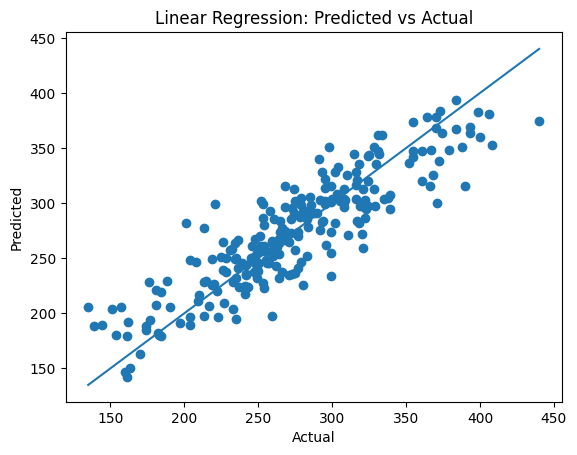

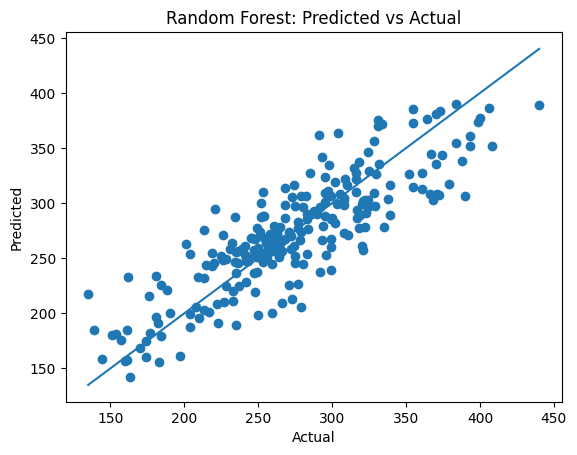

In [6]:
import matplotlib.pyplot as plt

# Linear Regression Plot
plt.scatter(y_test, y_pred_lr)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()])
plt.title("Linear Regression: Predicted vs Actual")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.show()

# Random Forest Plot
plt.scatter(y_test, y_pred_rf)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()])
plt.title("Random Forest: Predicted vs Actual")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.show()

Feature Importance (Random Forest)

In [7]:
# Get feature names after preprocessing
ohe = rf_pipeline.named_steps['preprocessing'].named_transformers_['cat']
encoded_features = ohe.get_feature_names_out(categorical_cols)

all_features = list(encoded_features) + numerical_cols

# Get importances
importances = rf_pipeline.named_steps['model'].feature_importances_

feature_importance_df = pd.DataFrame({
    'feature': all_features,
    'importance': importances
}).sort_values(by='importance', ascending=False)

feature_importance_df.head(5)

,feature,importance
14,is_festival,0.173420
10,store_size_small,0.166921
7,location_type_urban,0.108035
17,day_of_week,0.083147
13,is_weekend,0.064329


The top 5 features show which factors most influence sales.
For example:

. Promotions may strongly impact items sold
. Month or weekend indicators capture seasonal trends
. Competition density affects customer choice

This helps businesses optimise pricing, promotions, and store strategies.